In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yaml

In [3]:
import numpy as np
import os
import pandas as pd
import random
from pathlib import Path

from src.electrical_signature_frequencies import ANOMALY_FREQS
import matplotlib.pyplot as plt

import torch

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device 
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
print("Using device:", device)

Using device: cpu


In [4]:
from src.data_pipeline import create_metadata_df, load_measurement

In [5]:
state2name = {
    1: "rotor bar defect",  # Rotor cage break
    2: "normal",
    3: "bearing defect",
    4: "inter-turn short circuits"  # Stator inter-turn short-circuit
}

# Create metadata DataFrame
base_dir = "../dataset/engine_2"

path2metadata = os.path.join(base_dir, 'metadata.csv')
if os.path.isfile(path2metadata):
    metadata_df = pd.read_csv(os.path.join(path2metadata))
    metadata_df.set_index('measurement_id', inplace=True)
else:
    metadata_df = create_metadata_df(base_dir, state2name)
    metadata_df.to_csv(path2metadata)

In [6]:
metadata_df.phase.unique()

array([1, 3, 2])

In [7]:
condition = metadata_df.state.isin(['inter-turn short circuits', 'normal']) & (metadata_df.load_condition == 100)
metadata_df = metadata_df[condition]
metadata_df

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727937397_1,1727937397,experiment_1,inter-turn short circuits,100,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937357_1,1727937357,experiment_1,inter-turn short circuits,100,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937637_1,1727937637,experiment_1,inter-turn short circuits,100,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937757_1,1727937757,experiment_1,inter-turn short circuits,100,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937597_1,1727937597,experiment_1,inter-turn short circuits,100,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...,...,...
1727790891_2,1727790891,experiment_1,normal,100,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791230_2,1727791230,experiment_1,normal,100,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791150_2,1727791150,experiment_1,normal,100,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml


In [8]:
(metadata_df.reset_index().groupby('base_id')['measurement_id'].count() != 3).sum()

np.int64(0)

In [9]:
metadata_df.loc[metadata_df.state == 'normal', 'state'] = 'NF'
metadata_df.loc[metadata_df.state == 'inter-turn short circuits', 'state'] = 'SC'
metadata_df.drop(['load_condition', 'experiment'], axis=1, inplace=True)
metadata_df

,base_id,state,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,
1727937397_1,1727937397,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937357_1,1727937357,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937637_1,1727937637,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937757_1,1727937757,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937597_1,1727937597,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...
1727790891_2,1727790891,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791230_2,1727791230,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791150_2,1727791150,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml


In [10]:
metadata_df[metadata_df.state == 'SC']

,base_id,state,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,
1727937397_1,1727937397,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937357_1,1727937357,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937637_1,1727937637,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937757_1,1727937757,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937597_1,1727937597,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...
1727937377_2,1727937377,SC,2,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937558_2,1727937558,SC,2,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937617_2,1727937617,SC,2,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml


In [11]:
metadata_df[metadata_df.state == 'NF']

,base_id,state,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,
1727791012_1,1727791012,NF,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791211_1,1727791211,NF,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727790910_1,1727790910,NF,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727790870_1,1727790870,NF,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791170_1,1727791170,NF,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...
1727790891_2,1727790891,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791230_2,1727791230,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791150_2,1727791150,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml


In [12]:
real_df = metadata_df[metadata_df.base_id.isin([1727791012, 1727937397])]
real_df

,base_id,state,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,
1727937397_1,1727937397,SC,1,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937397_3,1727937397,SC,3,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727937397_2,1727937397,SC,2,16384,../dataset/engine_2/experiment_1/current/4th_l...,../dataset/engine_2/engine.yml
1727791012_1,1727791012,NF,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791012_3,1727791012,NF,3,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791012_2,1727791012,NF,2,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml


In [13]:
simulated_files = list(map(str, Path('../Faulty_AC_motor_001').glob('1_*.csv')))
simulated_df = pd.DataFrame({'file_path': simulated_files})

In [14]:
def get_phase(x):
    phase = x.split('\\')[2].split('_')[-1].split('.')[0]
    return 1 if phase == 'phaseA' else 2 if phase == 'phaseB' else 3

def get_state(x):
    signal_type = x.split('\\')[2].split('_')[1]
    return 'NF' if signal_type == 'nofault' else 'SC'

def get_num_observations(x):
    return pd.read_csv(x).shape[0]

def get_measurement_id(x):
    return f'{x.state}_{x.phase}'

simulated_df['state'] = simulated_df.file_path.apply(get_state)
simulated_df['phase'] = simulated_df.file_path.apply(get_phase)
simulated_df['num_observations'] = simulated_df.file_path.apply(get_num_observations)
simulated_df['measurement_id'] = simulated_df.apply(get_measurement_id, axis=1)
simulated_df = simulated_df.reset_index(drop=True).set_index('measurement_id')
simulated_df

,file_path,state,phase,num_observations
measurement_id,,,,
NF_1,..\Faulty_AC_motor_001\1_nofault_load100_phase...,NF,1,16666
NF_2,..\Faulty_AC_motor_001\1_nofault_load100_phase...,NF,2,16666
NF_3,..\Faulty_AC_motor_001\1_nofault_load100_phase...,NF,3,16666
SC_1,..\Faulty_AC_motor_001\1_shortcircuit_load100_...,SC,1,16666
SC_2,..\Faulty_AC_motor_001\1_shortcircuit_load100_...,SC,2,16666
SC_3,..\Faulty_AC_motor_001\1_shortcircuit_load100_...,SC,3,16666


In [ ]:
real_measurement_NF = '1727791012_1'
sim_measurement_NF= 'NF_1'
real_measurement_SC = '1727937397_1'
sim_measurement_SC = 'SC_1'

real_df_NF = load_measurement(real_measurement_NF, real_df)
#real_df_NF.fillna(0, inplace=True)
sim_df_NF = load_measurement(sim_measurement_NF, simulated_df)
#sim_df_NF.fillna(0, inplace=True)
real_df_SC = load_measurement(real_measurement_SC, real_df)
#real_df_SC.fillna(0, inplace=True)
sim_df_SC = load_measurement(sim_measurement_SC, simulated_df)
#sim_df_SC.fillna(0, inplace=True)

In [16]:
real_df_NF

,Current
Time,
0.000000,2.347748
0.244141,2.183217
0.488281,1.976231
0.732422,1.743942
0.976562,1.511428
...,...
3998.779297,-1.632223
3999.023438,-1.903840
3999.267578,-2.114818


In [17]:
sim_df_NF.index = sim_df_NF.index * 1000
sim_df_SC.index = sim_df_SC.index * 1000
sim_df_NF

,Current
Time,
0.32,2.300423
0.56,1.795470
0.80,1.109027
1.04,2.223509
1.28,0.618541
...,...
3998.96,3.268361
3999.20,3.150463
3999.44,2.352889


In [18]:
import plotly.express as px

fig = px.line(
    real_df_NF,
    x=real_df_NF.index,
    y='Current',
    title=f'Real Signal Over Time (no faults). ID: {real_measurement_NF}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

In [19]:
fig = px.line(
    real_df_SC,
    x=real_df_SC.index,
    y='Current',
    title=f'Real Signal Over Time (short circuit). ID: {real_measurement_SC}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

In [20]:
fig = px.line(
    sim_df_NF,
    x=sim_df_NF.index,
    y='Current',
    title=f'Simulated Signal Over Time (no faults). ID: {sim_measurement_NF}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

In [21]:
fig = px.line(
    sim_df_SC,
    x=sim_df_SC.index,
    y='Current',
    title=f'Simulated Signal Over Time (short circuit). ID: {sim_measurement_SC}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

In [22]:
# Load training parameters from train.yml
with open("../training_configs/train_engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

# Processing Parameters
f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]

# Training Parameters
num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

# Data Parameters
batch_size = train_params["data_parameters"]["batch_size"]

# Dataset Parameters
normalization_method = train_params["dataset_parameters"]["normalization_method"]

train_params

{'engineLabel': 'engine_2',
 'task': 'binary',
 'test_run': True,
 'comet_online': True,
 'seed': 42,
 'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'db': True,
  'peak_type': 'gaussian',
  'peak_segment': 4,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [0, 20, 40, 60, 80, 100],
  'phases_to_use': [1, 2, 3]},
 'model_parameters': {'attention_module': True, 'dropout': 0.2},
 'training_parameters': {'num_epochs_binary': 30,
  'num_epochs_multi': 30,
  'initial_lr': 0.001,
  'patience': 10},
 'data_parameters': {'batch_size': 512},
 'dataset_parameters': {'test_size': 0.3,
  'val_size': 0.2,
  'normalization_method': 'min-max',
  'normalization_mode': 'global',
  'train_dataset_cls': 'HybridAugFaultDataset',
  'train_dataset_kw

In [23]:
from src.data_pipeline import segment_signal, perform_fft_on_segments

# Segment the time-series data (dropna cause phase 3 has a missing value)
real_segments_NF = segment_signal(
    real_df_NF['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

real_segments_SC = segment_signal(
    real_df_SC['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

print(f'Shape: {real_segments_NF.shape[0]} segments of size {real_segments_NF.shape[1]}')
print(f'Shape: {real_segments_SC.shape[0]} segments of size {real_segments_SC.shape[1]}')

Shape: 320 segments of size 10000
Shape: 320 segments of size 10000


In [24]:
# Perform FFT on each segment
real_fft_NF, real_freqs_NF = perform_fft_on_segments(
    real_segments_NF, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq
)

real_fft_NF_1, real_freqs_NF_1 = perform_fft_on_segments(
    real_segments_NF, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq * 100
)

real_fft_SC, real_freqs_SC = perform_fft_on_segments(
    real_segments_SC, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq
)

real_fft_SC_1, real_freqs_SC_1 = perform_fft_on_segments(
    real_segments_SC, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq * 100
)

In [25]:
print(f'Shape: {real_fft_NF.shape[0]} segments of size {real_fft_NF.shape[1]}')
print(f'Shape: {real_fft_SC.shape[0]} segments of size {real_fft_SC.shape[1]}')

Shape: 320 segments of size 611
Shape: 320 segments of size 611


In [26]:
# Segment the time-series data (dropna cause phase 3 has a missing value)
sim_segments_NF = segment_signal(
    sim_df_NF['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

sim_segments_SC = segment_signal(
    sim_df_SC['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

print(f'Shape: {sim_segments_NF.shape[0]} segments of size {sim_segments_NF.shape[1]}')
print(f'Shape: {sim_segments_SC.shape[0]} segments of size {sim_segments_SC.shape[1]}')

Shape: 334 segments of size 10000
Shape: 334 segments of size 10000


In [27]:
f_sampling_sim = 12800

# Perform FFT on each segment
sim_fft_NF, sim_freqs_NF = perform_fft_on_segments(
    sim_segments_NF, 
    f_sampling_sim, 
    db=True, 
    cutoff_freq=cutoff_freq
)

sim_fft_NF_1, sim_freqs_NF_1 = perform_fft_on_segments(
    sim_segments_NF, 
    f_sampling_sim, 
    db=True, 
    cutoff_freq=cutoff_freq * 100
)

sim_fft_SC, sim_freqs_SC = perform_fft_on_segments(
    sim_segments_SC, 
    f_sampling_sim, 
    db=True, 
    cutoff_freq=cutoff_freq
)

sim_fft_SC_1, sim_freqs_SC_1 = perform_fft_on_segments(
    sim_segments_SC, 
    f_sampling_sim, 
    db=True, 
    cutoff_freq=cutoff_freq * 100
)

In [28]:
print(f'Shape: {sim_fft_NF.shape[0]} segments of size {sim_fft_NF.shape[1]}')
print(f'Shape: {sim_fft_SC.shape[0]} segments of size {sim_fft_SC.shape[1]}')

Shape: 334 segments of size 196
Shape: 334 segments of size 196


In [29]:
from scipy.signal import resample

def plot_single_segment_with_uncertainty(fft_segments, x_values=None, max_points=1000, n_std=2, title="Spectrum with Uncertainty",
                                         axis_labels=None, highlight_freqs=None, method='closest'):
    """
    Plots the average spectrum with uncertainty boundaries and highlights specific frequencies.

    Parameters:
    - fft_segments: 2D array of FFT segments (rows are segments, columns are data points).
    - x_values: Optional x-axis values corresponding to the spectrum.
    - max_points: Maximum number of points to plot (applies resampling if necessary).
    - n_std: Number of standard deviations for the uncertainty boundary.
    - title: Title for the spectrum.
    - axis_labels: Optional tuple (x_label, y_label) for axis labels.
    - highlight_freqs: List or array of frequencies to highlight on the plot.
    - method: Method to match highlight frequencies ('closest' matches nearest values).
    """
    # Calculate mean and standard deviation
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std  # Scale by number of standard deviations

    # Prepare x-values
    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = resample(spectrum_mean, max_points)
        spectrum_std = resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = resample(x_values, max_points)
            else:
                x_values = resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    # Plot
    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )
    # Add thicker boundary lines for the shaded region
    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    
    # Highlight specified frequencies
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                # Find the closest frequency in the x_values
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig, ax

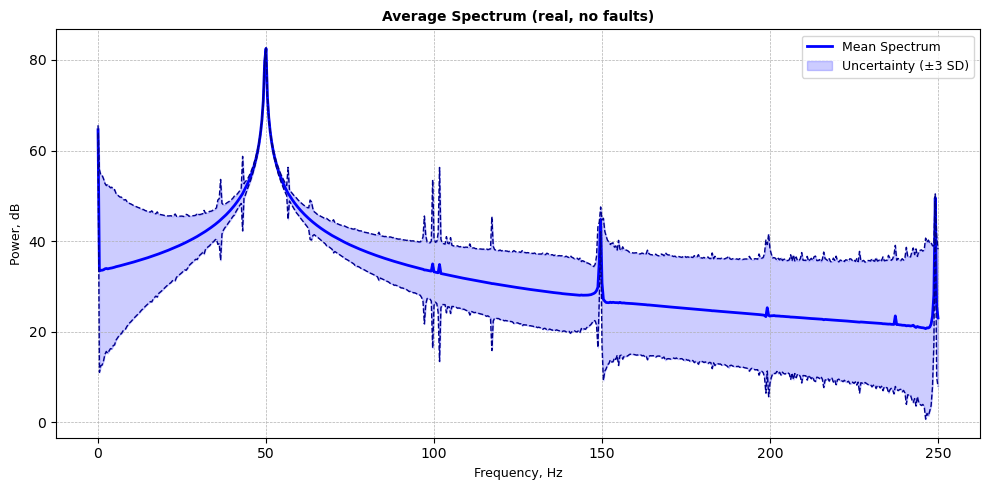

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average Spectrum (real, no faults)'}, xlabel='Frequency, Hz', ylabel='Power, dB'>)

In [30]:
plot_single_segment_with_uncertainty(real_fft_NF, 
                                     x_values=real_freqs_NF, 
                                     n_std=3, 
                                     title='Average Spectrum (real, no faults)')

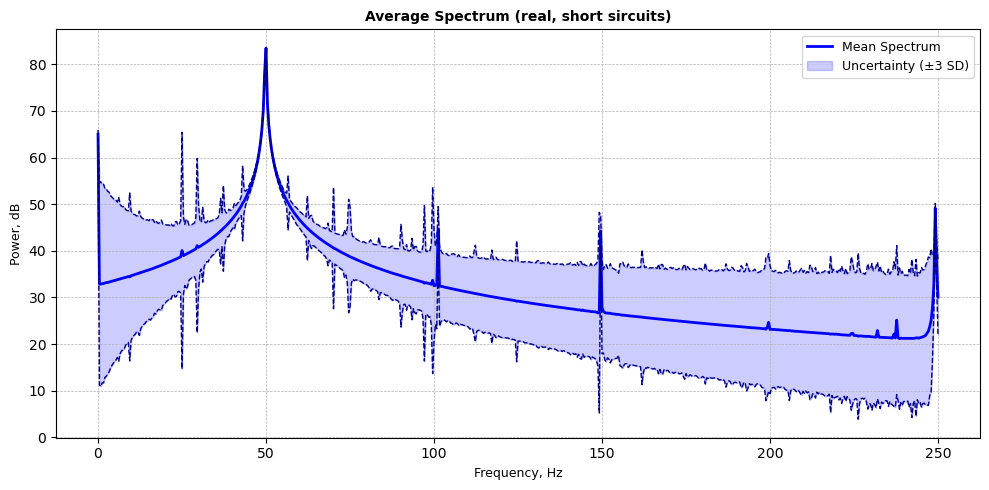

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average Spectrum (real, short sircuits)'}, xlabel='Frequency, Hz', ylabel='Power, dB'>)

In [31]:
plot_single_segment_with_uncertainty(real_fft_SC, 
                                     x_values=real_freqs_SC, 
                                     n_std=3, 
                                     title='Average Spectrum (real, short sircuits)')

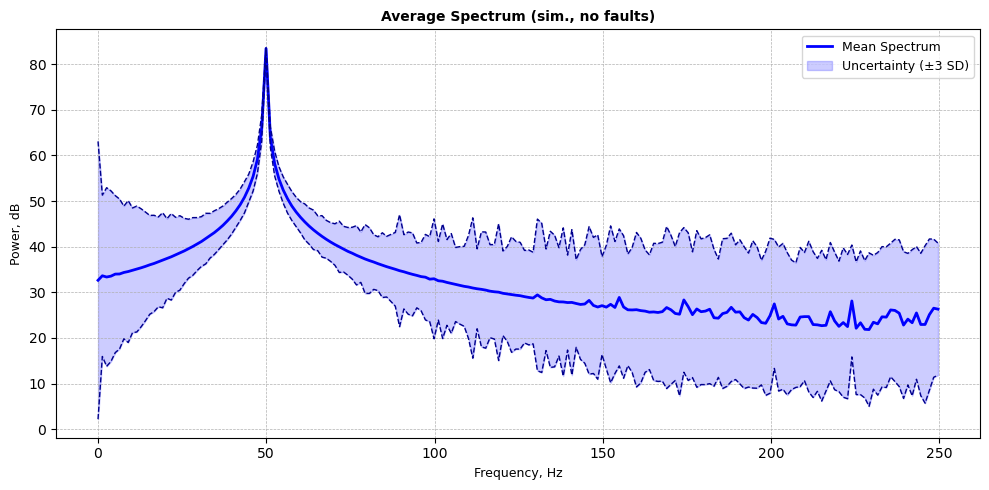

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average Spectrum (sim., no faults)'}, xlabel='Frequency, Hz', ylabel='Power, dB'>)

In [32]:
plot_single_segment_with_uncertainty(sim_fft_NF, 
                                     x_values=sim_freqs_NF, 
                                     n_std=3, 
                                     title='Average Spectrum (sim., no faults)')

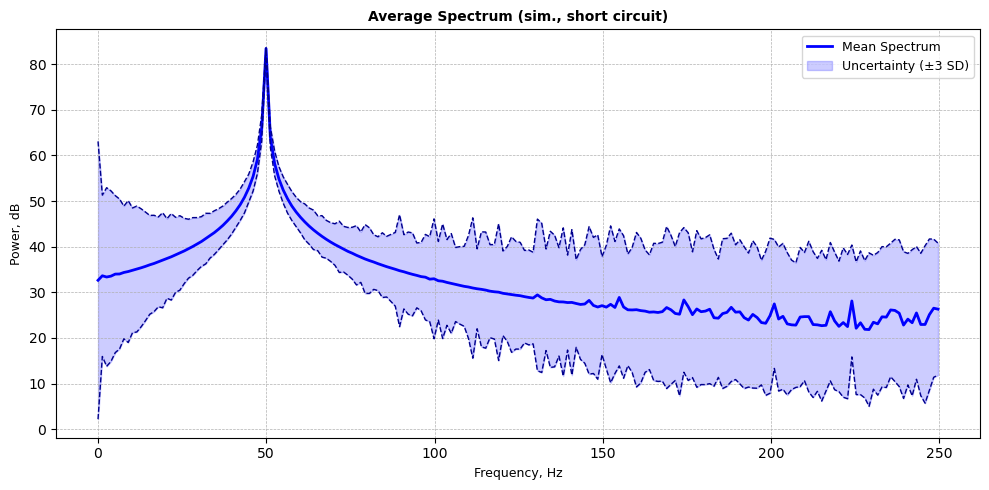

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average Spectrum (sim., short circuit)'}, xlabel='Frequency, Hz', ylabel='Power, dB'>)

In [33]:
plot_single_segment_with_uncertainty(sim_fft_SC, 
                                     x_values=sim_freqs_SC, 
                                     n_std=3, 
                                     title='Average Spectrum (sim., short circuit)')

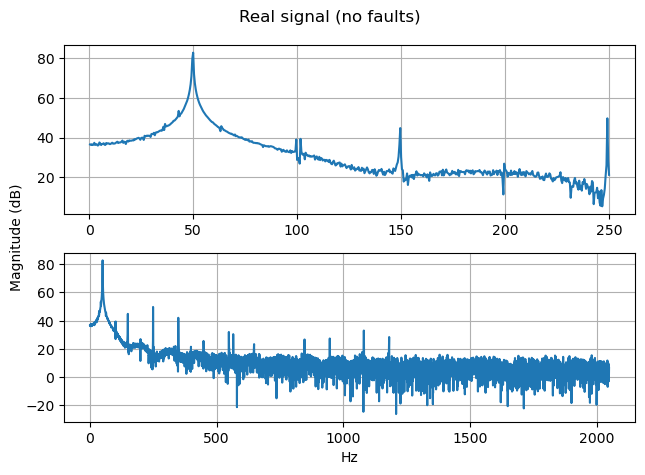

In [34]:
# Preprocessed signal visualization

idx = 0  # segment_index
fig, ax = plt.subplots(nrows=2, ncols=1)
ax[0].plot(real_freqs_NF[1:], real_fft_NF[idx, 1:])   # skip bin 0
ax[1].plot(real_freqs_NF_1[1:], real_fft_NF_1[idx, 1:]) 
ax[1].set_xlabel("Hz")
ax[0].grid()
ax[1].grid()
fig.text(s = 'Magnitude (dB)', x = 0, y = 0.4, rotation=90)
fig.suptitle('Real signal (no faults)')
plt.tight_layout()

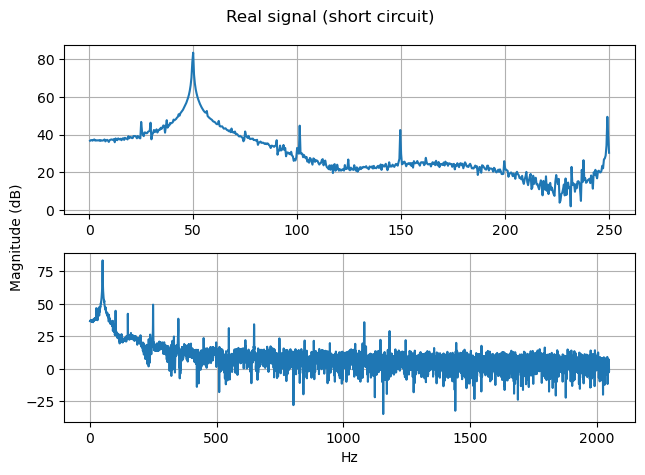

In [35]:
# Preprocessed signal visualization

idx = 0  # segment_index
fig, ax = plt.subplots(nrows=2, ncols=1)
ax[0].plot(real_freqs_SC[1:], real_fft_SC[idx, 1:])   # skip bin 0
ax[1].plot(real_freqs_SC_1[1:], real_fft_SC_1[idx, 1:]) 
ax[1].set_xlabel("Hz")
ax[0].grid()
ax[1].grid()
fig.text(s = 'Magnitude (dB)', x = 0, y = 0.4, rotation=90)
fig.suptitle('Real signal (short circuit)')
plt.tight_layout()

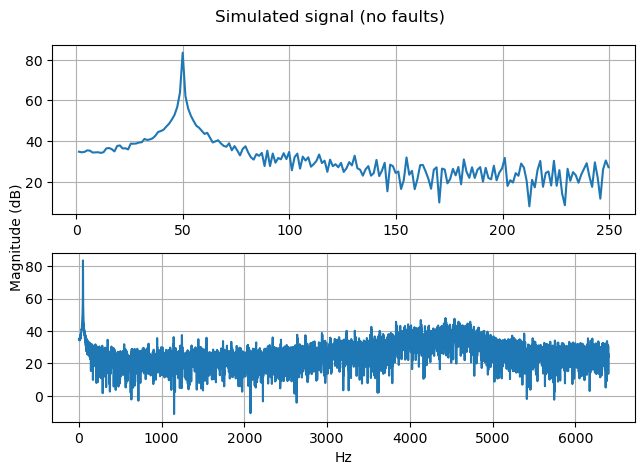

In [36]:
# Preprocessed signal visualization

idx = 0  # segment_index
fig, ax = plt.subplots(nrows=2, ncols=1)
ax[0].plot(sim_freqs_NF[1:], sim_fft_NF[idx, 1:])   # skip bin 0
ax[1].plot(sim_freqs_NF_1[1:], sim_fft_NF_1[idx, 1:]) 
ax[1].set_xlabel("Hz")
ax[0].grid()
ax[1].grid()
fig.text(s = 'Magnitude (dB)', x = 0, y = 0.4, rotation=90)
fig.suptitle('Simulated signal (no faults)')
plt.tight_layout()

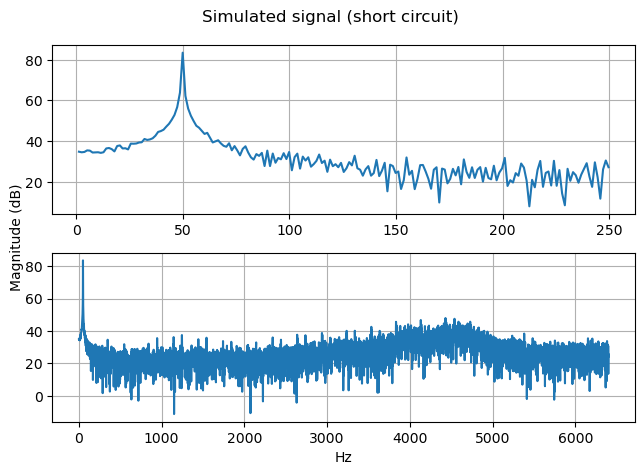

In [37]:
# Preprocessed signal visualization

idx = 0  # segment_index
fig, ax = plt.subplots(nrows=2, ncols=1)
ax[0].plot(sim_freqs_SC[1:], sim_fft_SC[idx, 1:])   # skip bin 0
ax[1].plot(sim_freqs_SC_1[1:], sim_fft_SC_1[idx, 1:]) 
ax[1].set_xlabel("Hz")
ax[0].grid()
ax[1].grid()
fig.text(s = 'Magnitude (dB)', x = 0, y = 0.4, rotation=90)
fig.suptitle('Simulated signal (short circuit)')
plt.tight_layout()

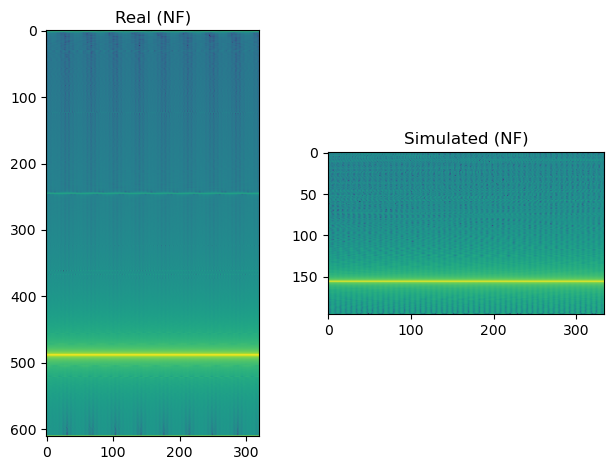

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].imshow(np.flip(real_fft_NF, axis=1).T)
ax[1].imshow(np.flip(sim_fft_NF, axis=1).T)
ax[0].set_title('Real (NF)')
ax[1].set_title('Simulated (NF)')
plt.tight_layout()

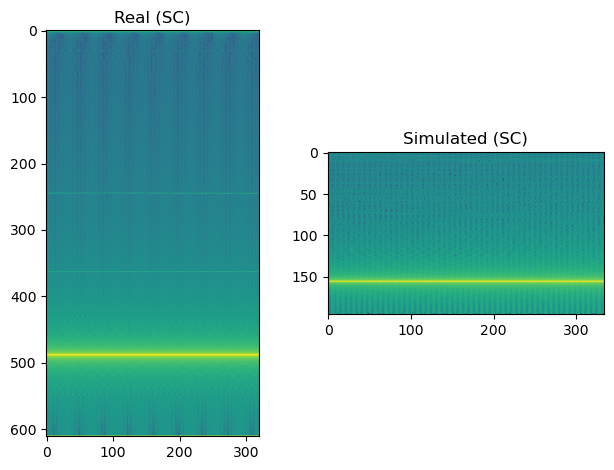

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].imshow(np.flip(real_fft_SC, axis=1).T)
ax[1].imshow(np.flip(sim_fft_SC, axis=1).T)
ax[0].set_title('Real (SC)')
ax[1].set_title('Simulated (SC)')
plt.tight_layout()

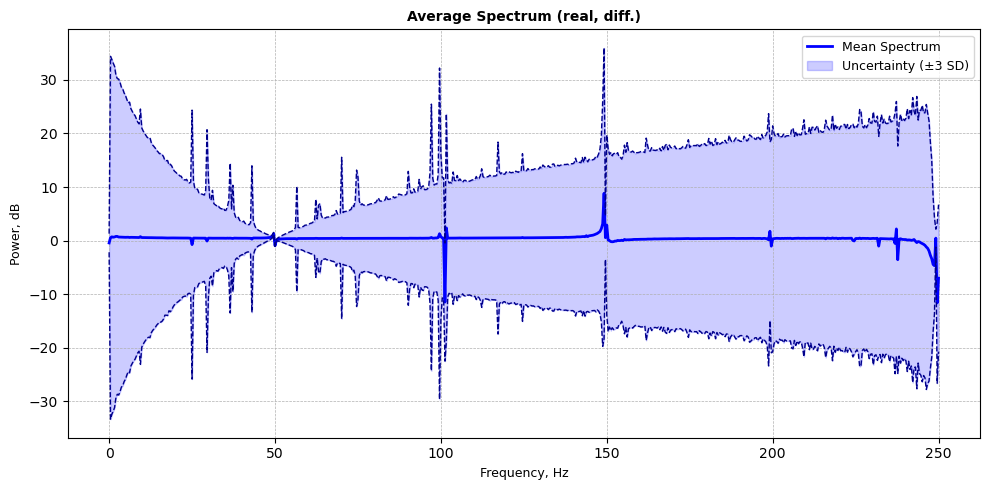

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average Spectrum (real, diff.)'}, xlabel='Frequency, Hz', ylabel='Power, dB'>)

In [40]:
plot_single_segment_with_uncertainty(real_fft_NF - real_fft_SC, 
                                     x_values=real_freqs_NF, 
                                     n_std=3, 
                                     title='Average Spectrum (real, diff.)')

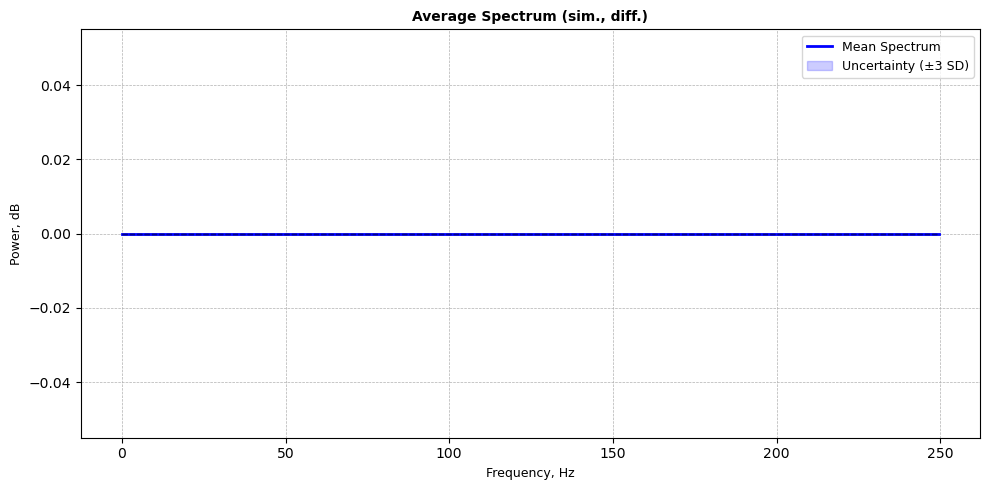

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average Spectrum (sim., diff.)'}, xlabel='Frequency, Hz', ylabel='Power, dB'>)

In [41]:
plot_single_segment_with_uncertainty(sim_fft_NF - sim_fft_SC, 
                                     x_values=sim_freqs_NF, 
                                     n_std=3, 
                                     title='Average Spectrum (sim., diff.)')

In [42]:
from typing import Tuple, List

import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from src.data_pipeline import segment_signal, perform_fft_on_segments

def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """
    Slice every measurement into fixed-length FFT segments
    and build a segment-level metadata table.

    Parameters
    ----------
    metadata_df : DataFrame
        The measurement-level table returned by `create_metadata_df`.
        MUST contain columns  ['state', 'phase', 'load_condition', 'experiment']
        and be indexed by 'measurement_id'.
    out_dir : str
        Directory where segments.npy and segments_metadata.csv are stored.
    segment_length, step, f_sampling, cutoff_freq, apply_window, db
        Usual DSP hyper-parameters (see notebook).

    Returns
    -------
    segments : np.ndarray
        Shape (total_segments, segment_length)
    seg_meta_df : DataFrame
        Multi-indexed by (measurement_id, segment_idx)
    """
    seg_meta_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []

    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        # 1) load measurement
        df = load_measurement(m_id, metadata_df)
        current = df["Current"].dropna().values

        # 2) slice time-domain windows
        windows = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )

        # 3) FFT
        fft_windows, freqs = perform_fft_on_segments(
            windows,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )

        # 4) per-segment rows
        n_segments = fft_windows.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_meta_rows.append({
                "measurement_id": m_id,
                "segment_idx":    s_idx,
                "start_time":     float(start_t),
                "end_time":       float(end_t),
                "state":          meta["state"],
                "binary_label":   0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":          int(meta["phase"]),
                "load_condition": meta["load_condition"],
                "experiment":     meta["experiment"],
            })
        seg_arrays.append(fft_windows.astype(np.float32))

    # 5) concat & persist
    segments = np.vstack(seg_arrays)  # (tot_segments, segment_length)
    seg_meta_df = (
        pd.DataFrame(seg_meta_rows)
          .set_index(["measurement_id", "segment_idx"])
    )

    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))

    return segments, seg_meta_df, freqs

In [43]:
real_df['load_condition'] = 100
simulated_df['load_condition'] = 100
real_df.loc[real_df['state'] == 'NF', 'state'] = 'normal'
simulated_df.loc[simulated_df['state'] == 'NF', 'state'] = 'normal'
real_df['experiment'] = 'experiment_1'
simulated_df['experiment'] = 'experiment_1'

C:\Users\mlsem\AppData\Local\Temp\ipykernel_13792\191010580.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\mlsem\AppData\Local\Temp\ipykernel_13792\191010580.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [44]:
real_seg, real_seg_meta, real_freqs = preprocessing(real_df,
                                                    'real_data',
                                                    segment_length,
                                                    shift,
                                                    f_sampling,
                                                    cutoff_freq
                                                    )

real_seg, real_seg_meta, real_freqs = preprocessing(simulated_df,
                                                    'sim_data',
                                                    segment_length,
                                                    shift,
                                                    f_sampling_sim,
                                                    cutoff_freq
                                                    )

pre-processing:   0%|          | 0/6 [00:00<?, ?it/s]

pre-processing:   0%|          | 0/6 [00:00<?, ?it/s]

D:\hse\Motor-Fault-Detection\src\visualization.py:244: RuntimeWarning:

Mean of empty slice.

c:\Users\mlsem\anaconda3\envs\py311_mfd\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning:

invalid value encountered in divide

c:\Users\mlsem\anaconda3\envs\py311_mfd\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning:

Degrees of freedom <= 0 for slice

c:\Users\mlsem\anaconda3\envs\py311_mfd\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning:

invalid value encountered in divide

c:\Users\mlsem\anaconda3\envs\py311_mfd\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning:

invalid value encountered in divide



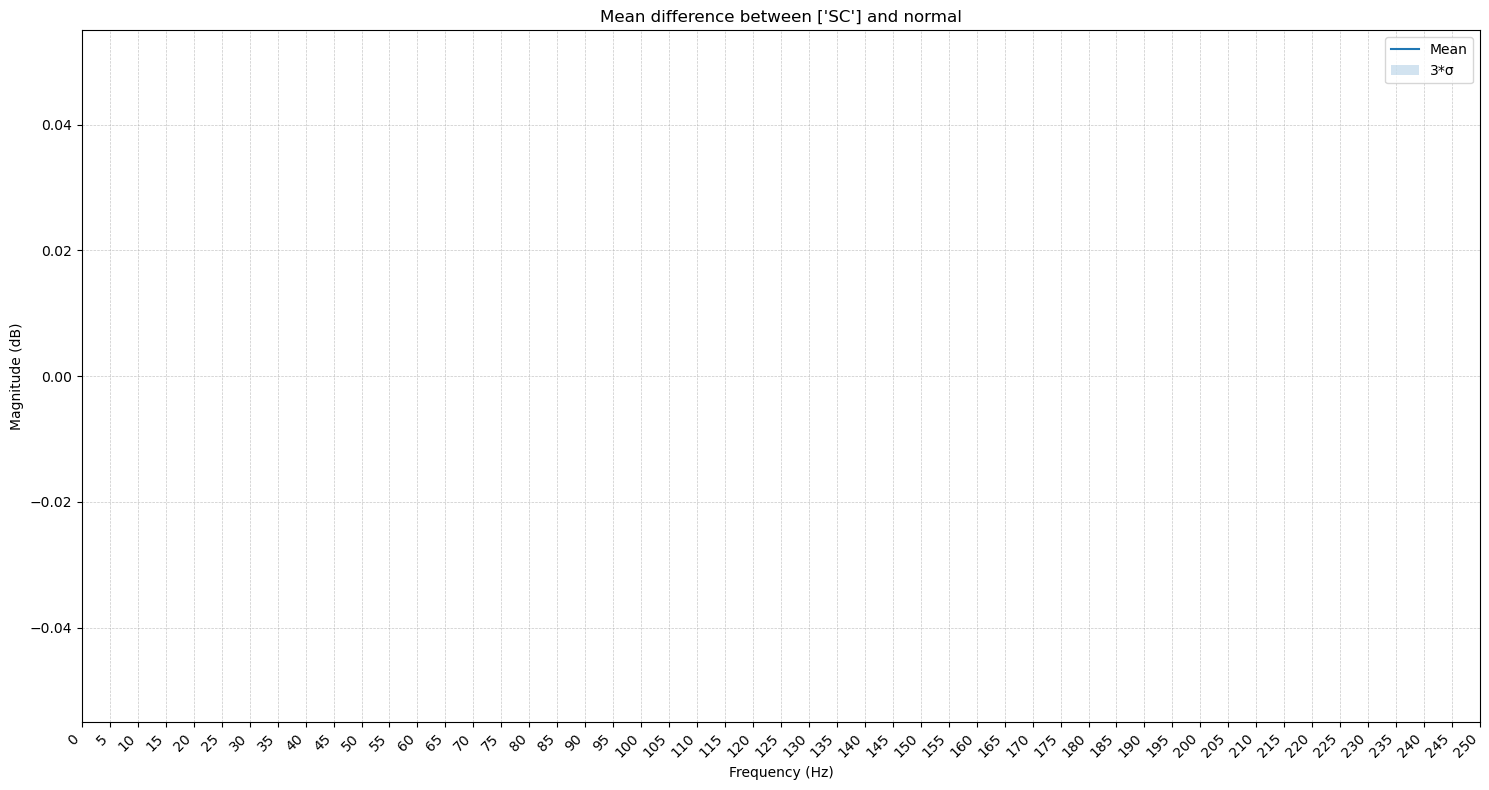

In [45]:
from src.visualization import plot_structural_deviations
from matplotlib.ticker import MaxNLocator

def plot_structural_deviations_with_freqs(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=3, ax=None):
    if ax is None:
        ax = plot_structural_deviations(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=k_sigma)
    else:
        ax = plot_structural_deviations(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=k_sigma, ax=ax)
    ax.set_title(f"Mean difference between {target_state} and normal")
    ax.legend(['Mean', f'{k_sigma}*σ', f'{target_state} FF'])
    ax.grid()
    ax.set_xlim(np.floor(freqs[0]), np.ceil(freqs[-1]))
    return ax

base_dir = "./real_data"

segments_path   = f"{base_dir}/segments.npy"
meta_path       = f"{base_dir}/segments_metadata.csv"
freqs_path      = f"{base_dir}/freqs.npy"

# Load
segments    = np.load(segments_path, mmap_mode="r")            # shape (n_segments, n_freq_bins)
seg_meta    = pd.read_csv(meta_path, index_col=["measurement_id", "segment_idx"])
freqs       = np.load(freqs_path)                              # length = n_freq_bins

# Classes
states = seg_meta.loc[seg_meta['state'] != 'normal', 'state'].unique()

n_xticks = len(freqs) // 10

loads = [100]
phases = [1]

n = 1
fig, axs = plt.subplots(n, 1, figsize=(15, 8*n))

for ax, target_state in zip([axs], [states]):
    ax = plot_structural_deviations_with_freqs(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=3, ax=ax)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks, integer=True, prune=None))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right") 
    ax.set_ylabel("Magnitude (dB)")
    
    # Grid behind the data, styled for visibility
    ax.set_axisbelow(True)
    ax.grid(
        True, which='major', axis='both',
        linestyle='--', linewidth=0.5, alpha=0.7
    )

axs.set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

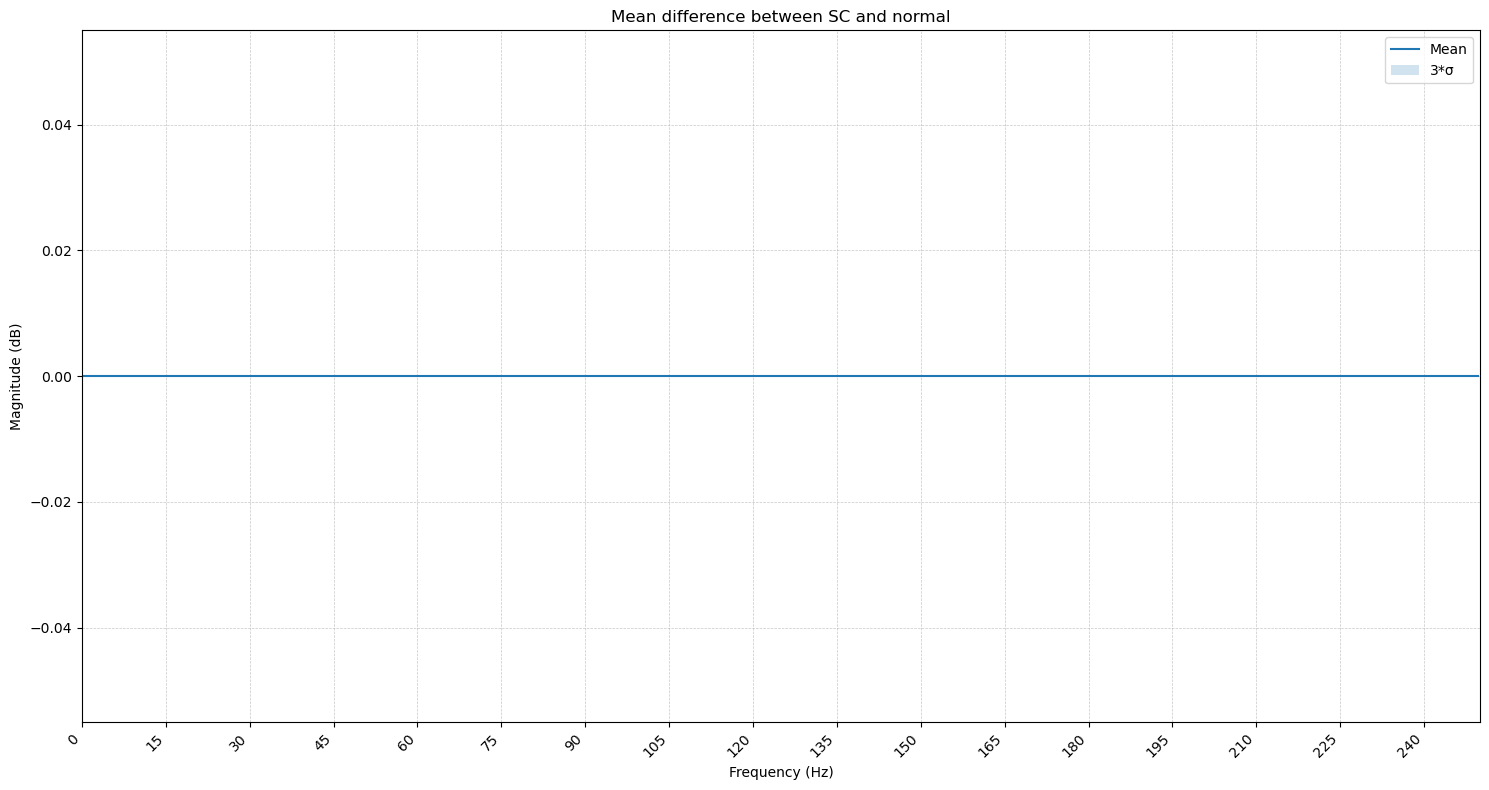

In [46]:
base_dir = "./sim_data"

segments_path   = f"{base_dir}/segments.npy"
meta_path       = f"{base_dir}/segments_metadata.csv"
freqs_path      = f"{base_dir}/freqs.npy"

# Load
segments    = np.load(segments_path, mmap_mode="r")            # shape (n_segments, n_freq_bins)
seg_meta    = pd.read_csv(meta_path, index_col=["measurement_id", "segment_idx"])
freqs       = np.load(freqs_path)                              # length = n_freq_bins

# Classes
states = seg_meta.loc[seg_meta['state'] != 'normal', 'state'].unique()

n_xticks = len(freqs) // 10

loads = [100]
phases = [1]

n = 1
fig, axs = plt.subplots(n, 1, figsize=(15, 8*n))

for ax, target_state in zip([axs], states):
    ax = plot_structural_deviations_with_freqs(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=3, ax=ax)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks, integer=True, prune=None))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right") 
    ax.set_ylabel("Magnitude (dB)")
    
    # Grid behind the data, styled for visibility
    ax.set_axisbelow(True)
    ax.grid(
        True, which='major', axis='both',
        linestyle='--', linewidth=0.5, alpha=0.7
    )

axs.set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()